# Exploring the use of TCAV on imagenet dataset and GoogleNet model. 
following this captum tutorial:
https://captum.ai/tutorials/TCAV_Image

In [1]:
!pip install captum


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 12.2 MB/s eta 0:00:0000:01


In [2]:
import numpy as np
import os, glob

import matplotlib.pyplot as plt

from PIL import Image

from scipy.stats import ttest_ind

# ..........torch imports............
import torch
import torchvision

from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms

#.... Captum imports..................
from captum.attr import LayerGradientXActivation, LayerIntegratedGradients

from captum.concept import TCAV
from captum.concept import Concept

from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str


In [3]:
!wget -q https://netdissect.csail.mit.edu/data/broden1_224.zip \
    -O /kaggle/working/broden.zip

!unzip -q /kaggle/working/broden.zip -d /kaggle/working/broden

## Defining image related transformations and functions

In [4]:
# Method to normalize an image to Imagenet mean and standard deviation
def transform(img):

    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
            ),
        ]
    )(img)


In [5]:
def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("RGB")
    return transform(img)


def load_image_tensors(class_name, root_path='/kaggle/input/datasets/kagglevladkh/imagenet1k-animals-mini', transform=True):
    path = os.path.join(root_path, class_name)
    filenames = glob.glob(path + '/*.jpg')

    tensors = []
    for filename in filenames:
        img = Image.open(filename).convert('RGB')
        tensors.append(transform(img) if transform else img)
    
    return tensors


In [6]:
def assemble_concept(name, id, concepts_path="data/tcav/image/concepts/"):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)

    return Concept(id=id, name=name, data_iter=concept_iter)


# Creating the concepts 

In [7]:
import shutil
from pathlib import Path

dtd_path = Path("/kaggle/working/broden/broden1_224/images/dtd")
concepts_path = Path("/kaggle/working/data/tcav/image/concepts")

concepts_path.mkdir(parents=True, exist_ok=True)

for concept in ["striped", "zigzagged", "dotted"]:
    destination = concepts_path / concept
    destination.mkdir(parents=True, exist_ok=True)

    images = [
        f for f in dtd_path.iterdir()
        if f.is_file()
        and f.name.startswith(concept + "_")
        and f.suffix.lower() in [".jpg", ".jpeg", ".png"]
        and "_color" not in f.stem
    ]

    for image in images:
        shutil.copy2(image, destination / image.name)

    print(f"{concept}: {len(images)} images copied")

striped: 120 images copied
zigzagged: 120 images copied
dotted: 120 images copied


In [8]:

stripes_concept = assemble_concept("striped", 0, concepts_path=concepts_path)
zigzagged_concept = assemble_concept("zigzagged", 1, concepts_path=concepts_path)
dotted_concept = assemble_concept("dotted", 2, concepts_path=concepts_path)



# Creating the random images

In [9]:
import random
import shutil
from pathlib import Path

# Tiny ImageNet train directory
imagenet_path = Path(
    "/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train"
)

# Where TCAV expects the concepts
concepts_path = Path("/kaggle/working/data/tcav/image/concepts")

# Collect all Tiny ImageNet images
image_extensions = {".jpg", ".jpeg", ".png"}

all_images = [
    p
    for p in imagenet_path.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print(f"Total candidate images: {len(all_images)}")

# Shuffle reproducibly
random.seed(42)
random.shuffle(all_images)

# We need 4 × 120 = 480 unique images
selected_images = all_images[:480]

# Create random_0 ... random_3
for i in range(4):
    concept_name = f"random_{i}"
    concept_dir = concepts_path / concept_name
    concept_dir.mkdir(parents=True, exist_ok=True)

    start = i * 120
    end = start + 120

    for image in selected_images[start:end]:
        shutil.copy2(image, concept_dir / image.name)

    print(f"{concept_name}: {end - start} images")

Total candidate images: 34745
random_0: 120 images
random_1: 120 images
random_2: 120 images
random_3: 120 images


In [10]:

random_0_concept = assemble_concept("random_0", 3, concepts_path=concepts_path)
random_1_concept = assemble_concept("random_1", 4, concepts_path=concepts_path)

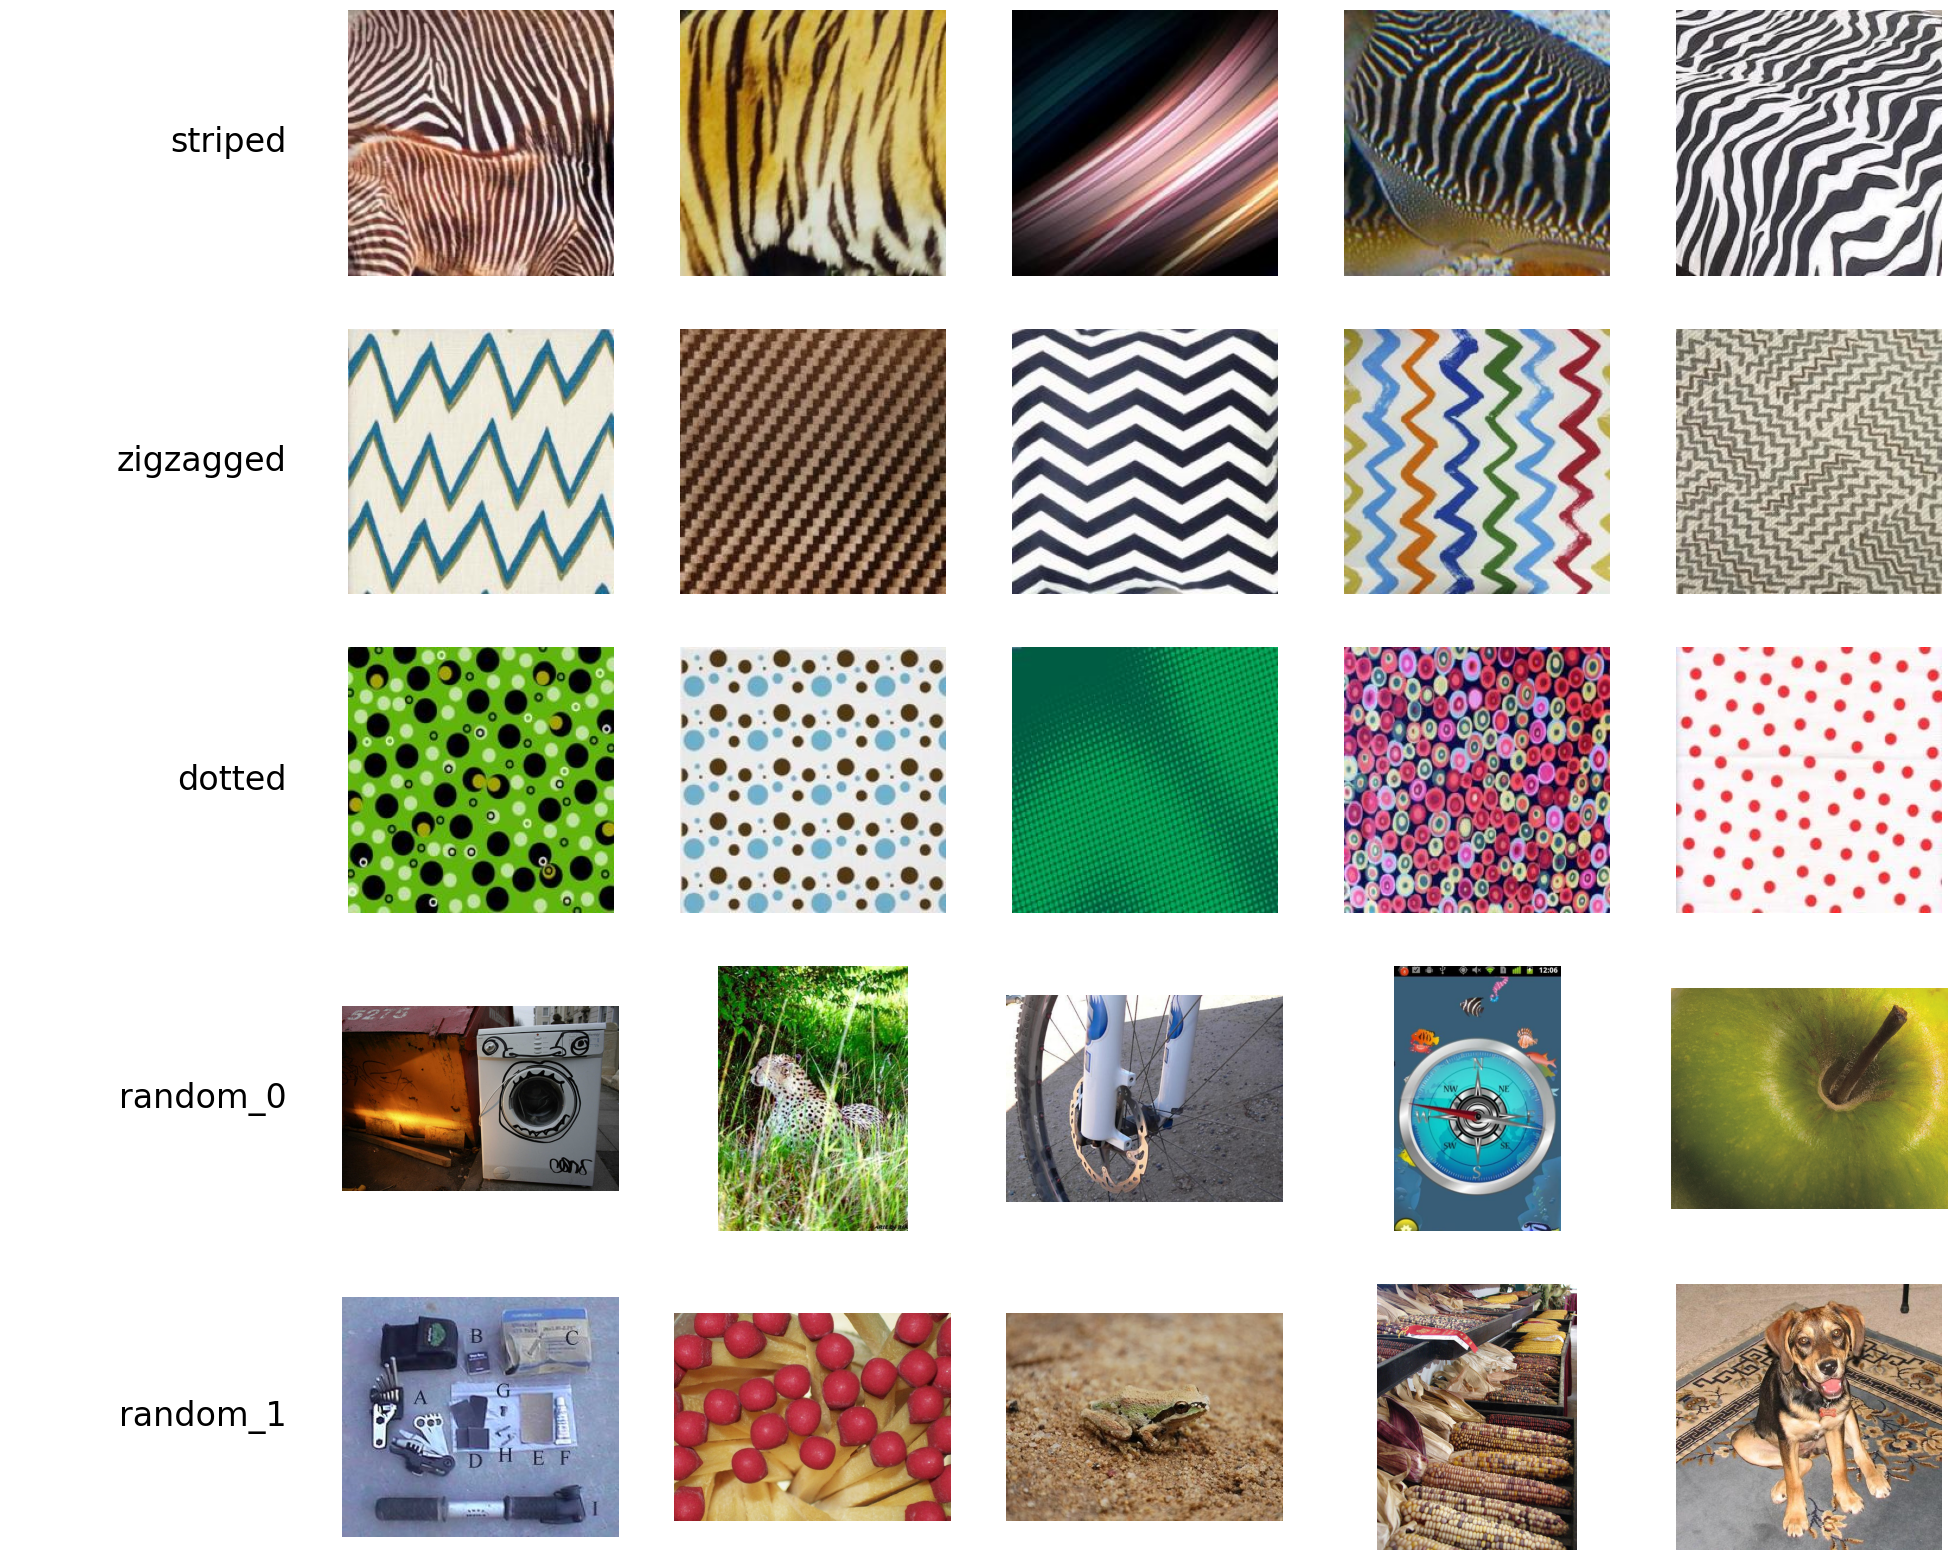

In [11]:
n_figs = 5
n_concepts = 5

fig, axs = plt.subplots(n_concepts, n_figs + 1, figsize = (25, 4 * n_concepts))

for c, concept in enumerate([stripes_concept, zigzagged_concept, dotted_concept, random_0_concept, random_1_concept]):
    concept_path = os.path.join(concepts_path, concept.name) + "/"
    img_files = glob.glob(concept_path + '*')
    for i, img_file in enumerate(img_files[:n_figs + 1]):
        if os.path.isfile(img_file):
            if i == 0:
                axs[c, i].text(1.0, 0.5, str(concept.name), ha='right', va='center', family='sans-serif', size=24)
            else:
                img = plt.imread(img_file)
                axs[c, i].imshow(img)

            axs[c, i].axis('off')


## Defining GoogleNet Model

For this tutorial, we will load GoogleNet model and set in eval mode.

In [12]:
model = torchvision.models.googlenet(pretrained=True)
model = model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 231MB/s]


# Computing TCAV Scores

In [13]:
layers=['inception4c', 'inception4d', 'inception4e']

mytcav = TCAV(model=model,
              layers=layers,
              layer_attr_method = LayerIntegratedGradients(
                model, None, multiply_by_inputs=False))


/usr/local/lib/python3.12/dist-packages/captum/concept/_core/tcav.py:330: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


##### Defining experimantal sets for CAV

In [14]:
experimental_set_rand = [[stripes_concept, random_0_concept], [stripes_concept, random_1_concept]]


In [15]:
# Load sample images from folder
zebra_imgs = load_image_tensors('zebra', transform=False)

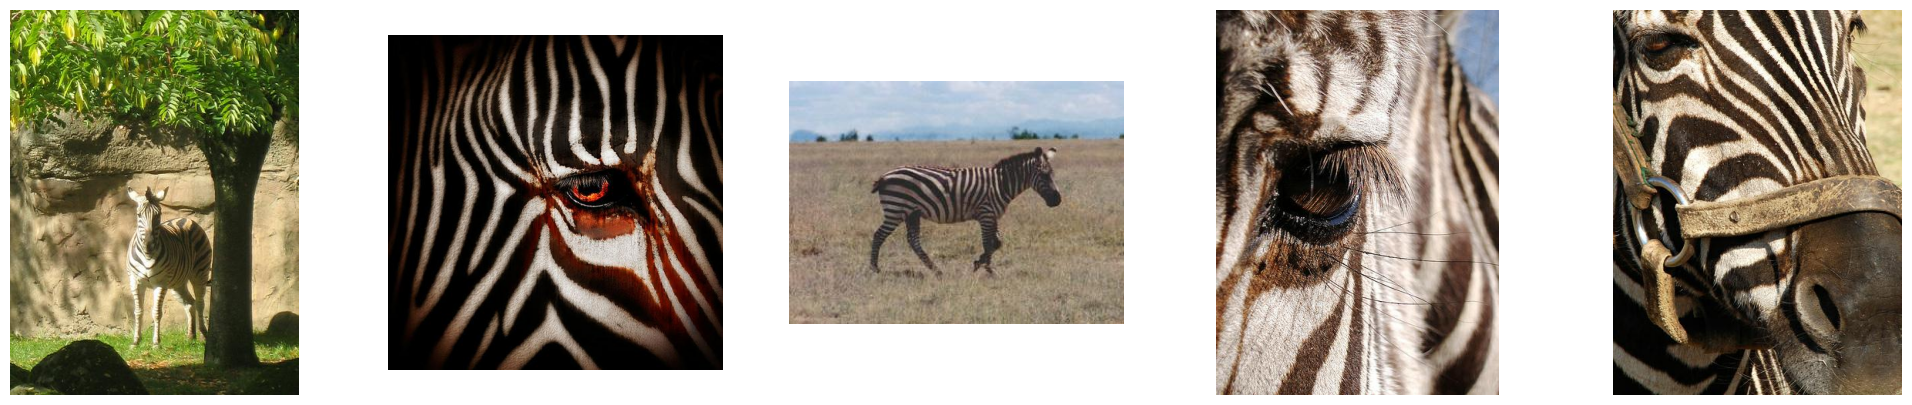

In [16]:
fig, axs = plt.subplots(1, 5, figsize = (25, 5))
axs[0].imshow(zebra_imgs[40])
axs[1].imshow(zebra_imgs[41])
axs[2].imshow(zebra_imgs[34])
axs[3].imshow(zebra_imgs[31])
axs[4].imshow(zebra_imgs[30])

axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[3].axis('off')
axs[4].axis('off')

plt.show()

In [17]:
# Load sample images from folder
zebra_tensors = torch.stack([transform(img) for img in zebra_imgs])
experimental_set_rand

[[Concept(0, 'striped'), Concept(3, 'random_0')],
 [Concept(0, 'striped'), Concept(4, 'random_1')]]

In [18]:
# zebra class index
zebra_ind = 340


tcav_scores_w_random = mytcav.interpret(inputs=zebra_tensors,
                                        experimental_sets=experimental_set_rand,
                                        target=zebra_ind,
                                        n_steps=5,
                                       )
tcav_scores_w_random

/usr/local/lib/python3.12/dist-packages/captum/_utils/models/linear_model/train.py:418: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


defaultdict(<function captum.concept._core.tcav.TCAV.interpret.<locals>.<lambda>()>,
            {'0-3': defaultdict(None,
                         {'inception4c': {'sign_count': tensor([0.6500, 0.3500]),
                           'magnitude': tensor([ 0.3758, -0.3758])},
                          'inception4d': {'sign_count': tensor([0.9900, 0.0100]),
                           'magnitude': tensor([ 1.1879, -1.1879])},
                          'inception4e': {'sign_count': tensor([1., 0.]),
                           'magnitude': tensor([ 0.7991, -0.7991])}}),
             '0-4': defaultdict(None,
                         {'inception4c': {'sign_count': tensor([0.9600, 0.0400]),
                           'magnitude': tensor([ 1.2733, -1.2733])},
                          'inception4d': {'sign_count': tensor([0.9900, 0.0100]),
                           'magnitude': tensor([ 1.4116, -1.4116])},
                          'inception4e': {'sign_count': tensor([1., 0.]),
                

Auxiliary functions for visualizing of TCAV scores.

In [19]:
def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores):
    fig, ax = plt.subplots(1, len(experimental_sets), figsize = (25, 7))

    barWidth = 1 / (len(experimental_sets[0]) + 1)

    for idx_es, concepts in enumerate(experimental_sets):

        concepts = experimental_sets[idx_es]
        concepts_key = concepts_to_str(concepts)

        pos = [np.arange(len(layers))]
        for i in range(1, len(concepts)):
            pos.append([(x + barWidth) for x in pos[i-1]])
        _ax = (ax[idx_es] if len(experimental_sets) > 1 else ax)
        for i in range(len(concepts)):
            val = [format_float(scores['sign_count'][i]) for layer, scores in tcav_scores[concepts_key].items()]
            _ax.bar(pos[i], val, width=barWidth, edgecolor='white', label=concepts[i].name)

        # Add xticks on the middle of the group bars
        _ax.set_xlabel('Set {}'.format(str(idx_es)), fontweight='bold', fontsize=16)
        _ax.set_xticks([r + 0.3 * barWidth for r in range(len(layers))])
        _ax.set_xticklabels(layers, fontsize=16)

        # Create legend & Show graphic
        _ax.legend(fontsize=16)

    plt.show()

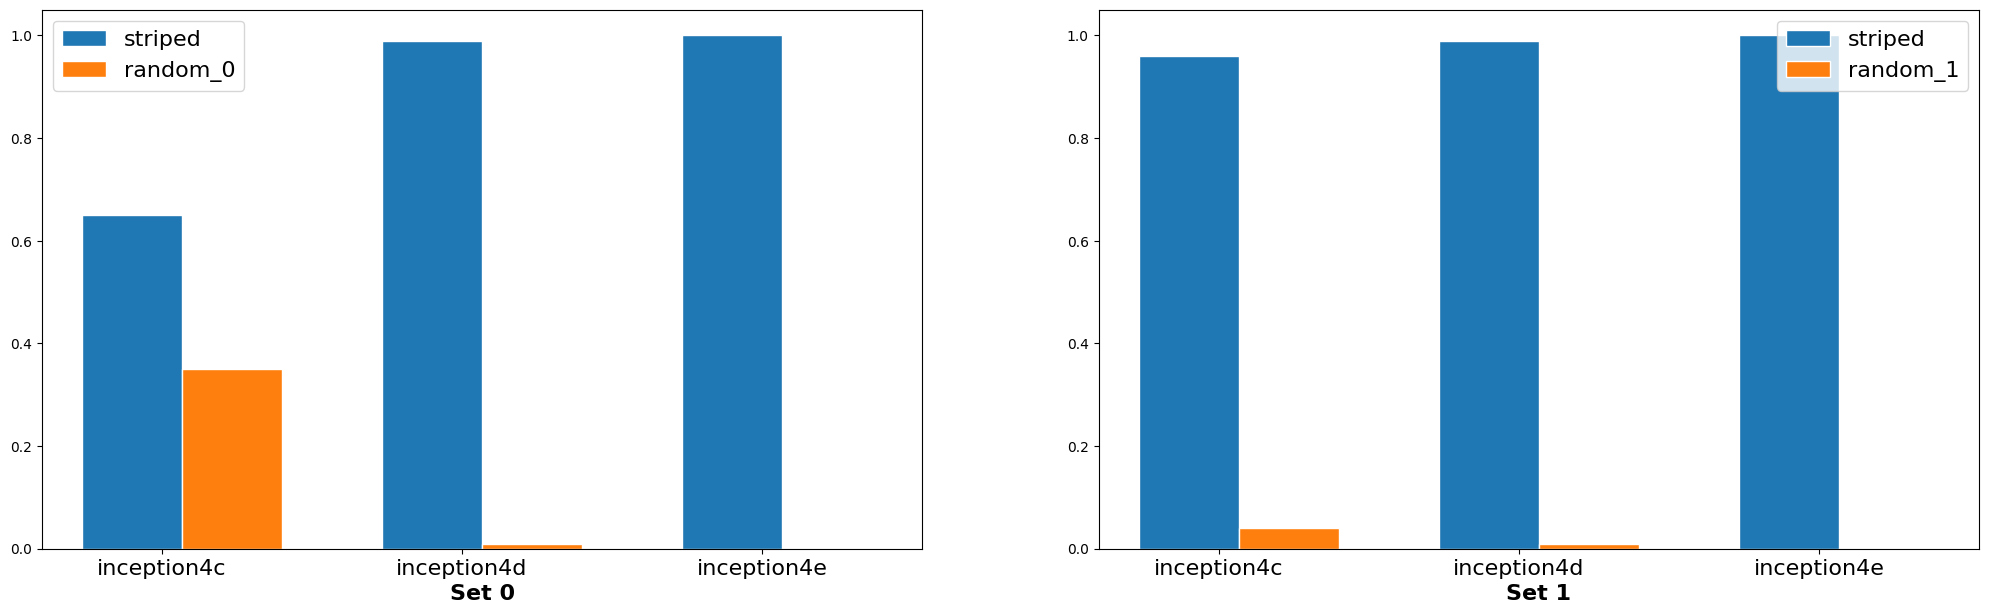

In [20]:

plot_tcav_scores(experimental_set_rand, tcav_scores_w_random)


In [21]:
experimental_set_zig_dot = [[stripes_concept, zigzagged_concept, dotted_concept]]


In [22]:

tcav_scores_w_zig_dot = mytcav.interpret(inputs=zebra_tensors,
                                         experimental_sets=experimental_set_zig_dot,
                                         target=zebra_ind,
                                         n_steps=5)


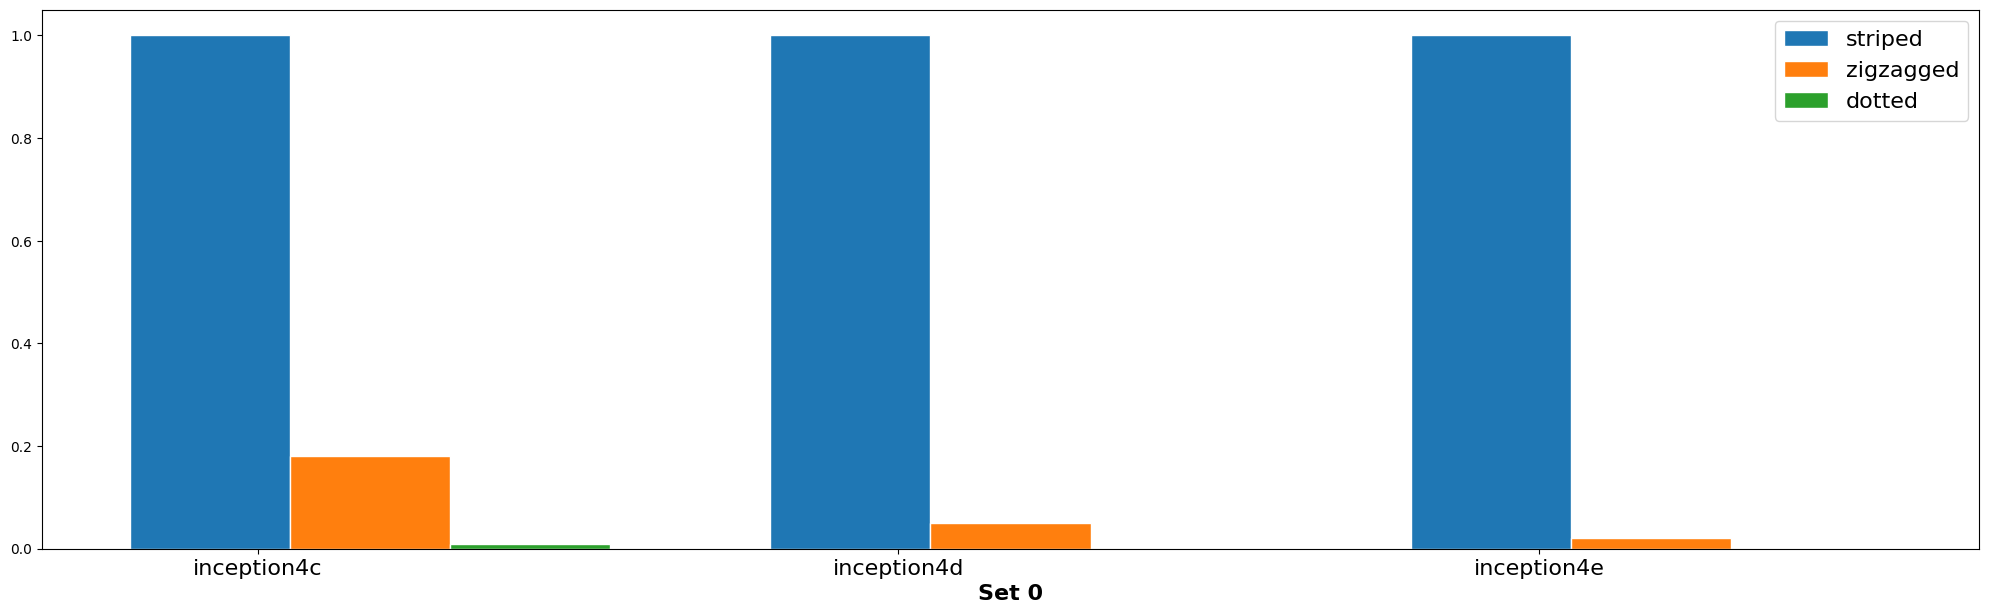

In [23]:
plot_tcav_scores(experimental_set_zig_dot, tcav_scores_w_zig_dot)    

Similar to the previous case in this experiment as well we observe that `striped` concept has very high TCAV scores across all  three layers compared to `zigzagged` and `dotted`. This means that the `striped` concept is an essential concept in predicting `zebra`.  

# Statistical significance testing of concepts

In order to convince ourselves that our concepts truly explain our predictions, we conduct statistical significance tests on TCAV scores by constructing a number of experimental sets. In this case we look into the `striped` concept and a number of random concepts.
If `striped` concept is truly important in predicting `zebra` in the images that contain `zebra`, then we will see consistent high TCAV scores for `striped` concept across all experimental sets as apposed to any other concept.

Each experimental set contains a random concept consisting of a number of random subsamples. In our case this allows us to estimate the robustness of TCAV scores by the means of numerous random concepts. 

Let's define those experimental sets in the cell below.


We will look into `striped`, and a number of random concepts drawn uniformly random from imagenet dataset.
```
concept_list = ['stripped', 'ceo', 'random_0', 'random_1', 'random2', ... , 'random_n'], n is the number of concepts
```

Then, we will construct pairs of experimental sets that contain pairs of two concepts. In this case:
```
experimental_sets = [['stripped', 'random_0'], ['stripped', 'random_1'], ... , ['striped', 'random_n'], 
                    ['random_0', 'random_1'], ['random_0', 'random_2'], ... , ['random_0', 'random_n']]
```

In [24]:
n = 2

random_concepts = [assemble_concept('random_' + str(i+2), i+5) for i in range(0, n)]

print(random_concepts)

experimental_sets = [[stripes_concept, random_0_concept], [stripes_concept, random_1_concept]]
experimental_sets.extend([[stripes_concept, random_concept] for random_concept in random_concepts])

experimental_sets.append([random_0_concept, random_1_concept])
experimental_sets.extend([[random_0_concept, random_concept] for random_concept in random_concepts])

experimental_sets

[Concept(5, 'random_2'), Concept(6, 'random_3')]


[[Concept(0, 'striped'), Concept(3, 'random_0')],
 [Concept(0, 'striped'), Concept(4, 'random_1')],
 [Concept(0, 'striped'), Concept(5, 'random_2')],
 [Concept(0, 'striped'), Concept(6, 'random_3')],
 [Concept(3, 'random_0'), Concept(4, 'random_1')],
 [Concept(3, 'random_0'), Concept(5, 'random_2')],
 [Concept(3, 'random_0'), Concept(6, 'random_3')]]

Now, let's define a convenience function for assembling the experiments together as lists of Concept objects, creating and running the TCAV:

In [25]:
def assemble_scores(scores, experimental_sets, idx, score_layer, score_type):
    score_list = []
    for concepts in experimental_sets:
        score_list.append(scores["-".join([str(c.id) for c in concepts])][score_layer][score_type][idx])
        
    return score_list

In addition, it is interesting to look into the p-values of statistical significance tests for each concept. We say, that we reject null hypothesis, if the p-value for concept's TCAV scores is smaller than 0.05. This indicates that the concept is important for model prediction.

We label concept populations as overlapping if p-value > 0.05 otherwise disjoint.

In [26]:
def get_pval(scores, experimental_sets, score_layer, score_type, alpha=0.05, print_ret=False):
    
    P1 = assemble_scores(scores, experimental_sets, 0, score_layer, score_type)
    P2 = assemble_scores(scores, experimental_sets, 1, score_layer, score_type)
    
    if print_ret:
        print('P1[mean, std]: ', format_float(np.mean(P1)), format_float(np.std(P1)))
        print('P2[mean, std]: ', format_float(np.mean(P2)), format_float(np.std(P2)))

    _, pval = ttest_ind(P1, P2)

    if print_ret:
        print("p-values:", format_float(pval))

    if pval < alpha:    # alpha value is 0.05 or 5%
        relation = "Disjoint"
        if print_ret:
            print("Disjoint")
    else:
        relation = "Overlap"
        if print_ret:
            print("Overlap")
        
    return P1, P2, format_float(pval), relation


We now run the TCAV and obtain the scores:

In [27]:
# Run TCAV
scores = mytcav.interpret(zebra_tensors, experimental_sets, zebra_ind, n_steps=5)

We can present the distribution of tcav scores using boxplots and the p-values indicating whether TCAV scores of those concepts are overlapping or disjoint.

In [28]:
n = 4
def show_boxplots(layer, metric='sign_count'):

    def format_label_text(experimental_sets):
        concept_id_list = [exp.name if i == 0 else \
                             exp.name.split('_')[0] for i, exp in enumerate(experimental_sets[0])]
        return concept_id_list

    n_plots = 2

    fig, ax = plt.subplots(1, n_plots, figsize = (25, 7 * 1))
    fs = 18
    for i in range(n_plots):
        esl = experimental_sets[i * n : (i+1) * n]
        P1, P2, pval, relation = get_pval(scores, esl, layer, metric)

        ax[i].set_ylim([0, 1])
        ax[i].set_title(layer + "-" + metric + " (pval=" + str(pval) + " - " + relation + ")", fontsize=fs)
        ax[i].boxplot([P1, P2], showfliers=True)

        ax[i].set_xticklabels(format_label_text(esl), fontsize=fs)

    plt.show()

Below box plots visualize the distribution of TCAV scores for two pairs of concepts in three different layers. Each layer is visualized in a separate jupyter cell. 
Below diagrams show that `striped` concept has TCAV scores that are consistently high across all layers and experimental sets as apposed to `random` concept. It also shows that `striped` and `random` are disjoint populations.

When we compare the populations of two random concepts we see that the p-value is much higher, meaning that those populations overlap and we cannot reject null hypothesis anymore. 

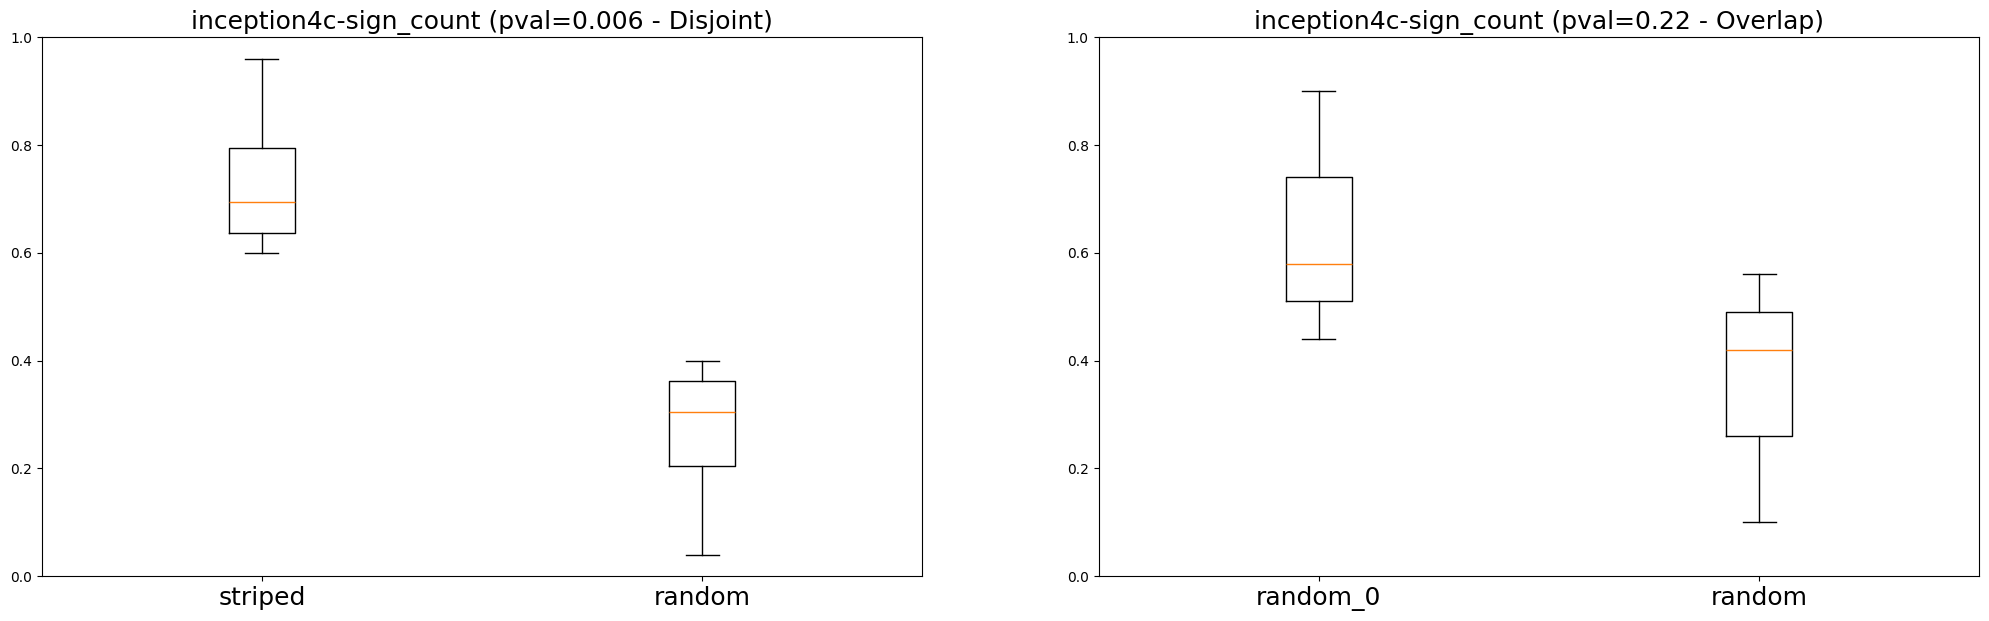

In [29]:
show_boxplots ("inception4c")

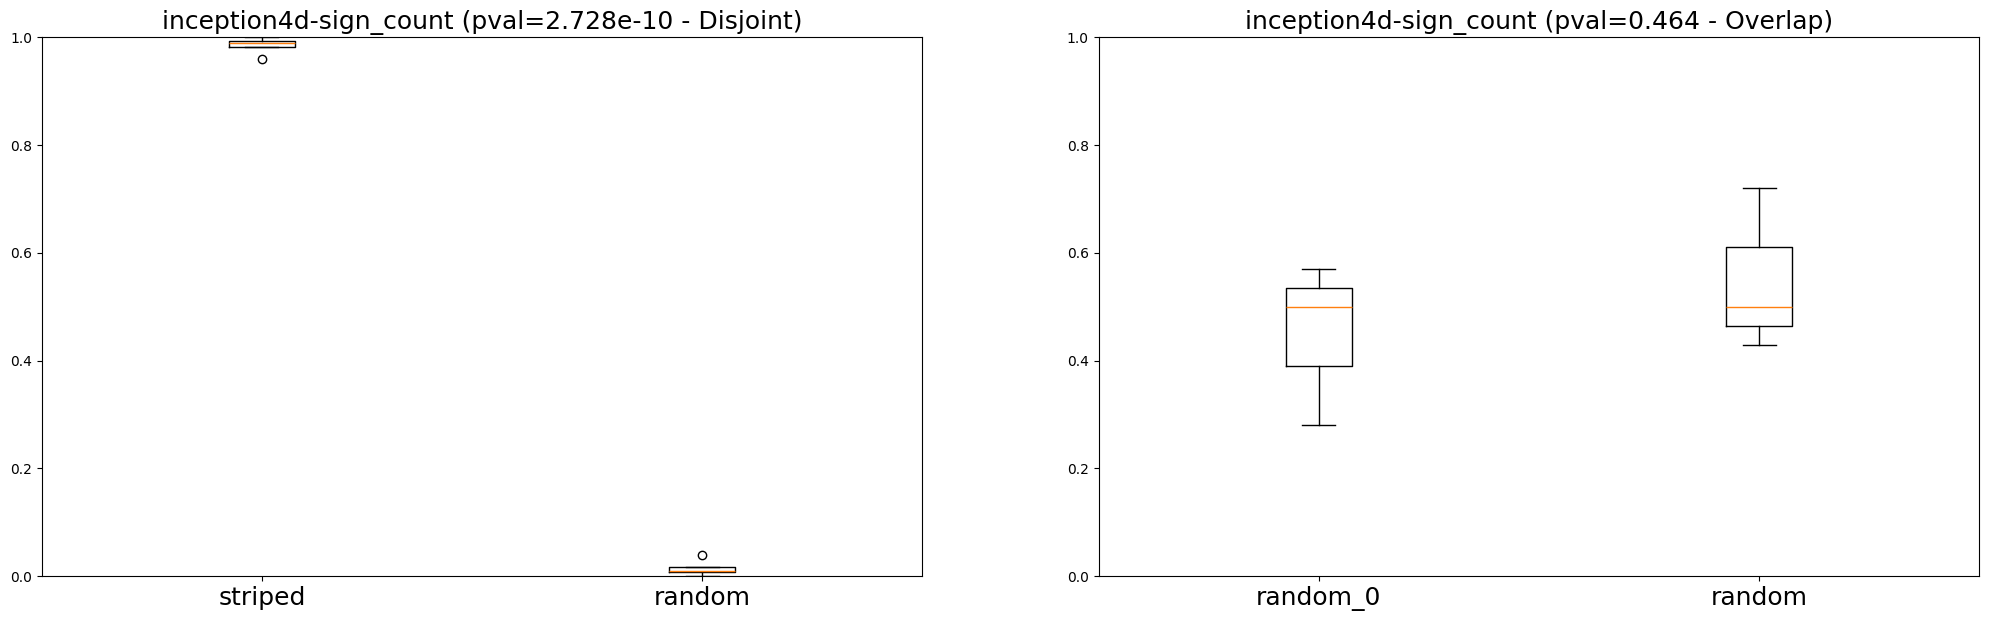

In [30]:
show_boxplots ("inception4d")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


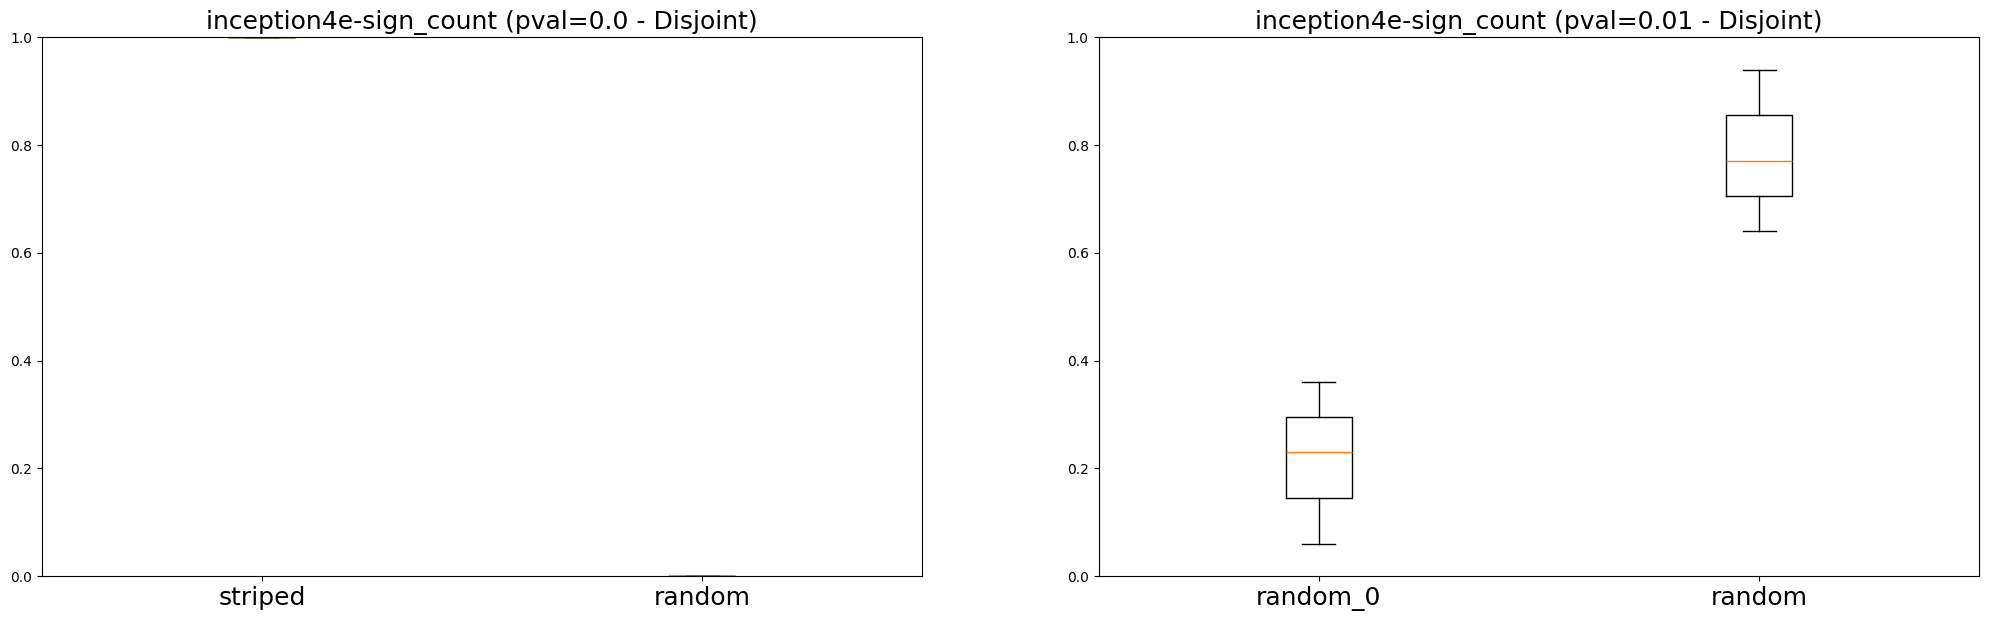

In [31]:
show_boxplots ("inception4e")